In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [2]:
import os 
os.getcwd()

'C:\\Users\\rutuj'

In [3]:
import pandas as pd 
data={
    "Gender":["Male","Male","Male","Female","Female","Female"],
    "Math_Score":[70,80,60,75,90,88],
    "Reading_Score":[80,90,60,88,97,96],
    "Writing_Score":[50,66,85,58,99,70]
}
df=pd.DataFrame(data)
print(df.head())



   Gender  Math_Score  Reading_Score  Writing_Score
0    Male          70             80             50
1    Male          80             90             66
2    Male          60             60             85
3  Female          75             88             58
4  Female          90             97             99


In [4]:
df.shape

(6, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Gender         6 non-null      object
 1   Math_Score     6 non-null      int64 
 2   Reading_Score  6 non-null      int64 
 3   Writing_Score  6 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 324.0+ bytes


In [6]:
df.describe()

,Math_Score,Reading_Score,Writing_Score
count,6.000000,6.000000,6.000000
mean,77.166667,85.166667,71.333333
std,11.321072,13.775582,17.974055
min,60.000000,60.000000,50.000000
25%,71.250000,82.000000,60.000000
50%,77.500000,89.000000,68.000000
75%,86.000000,94.500000,81.250000
max,90.000000,97.000000,99.000000


In [7]:
df.isnull().sum()	

Gender           0
Math_Score       0
Reading_Score    0
Writing_Score    0
dtype: int64

In [8]:
#Handle Missing Values	(Mean Imputation)
df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].mean()) 
df['Reading_Score'] = df['Reading_Score'].fillna(df['Reading_Score'].mean()) 
df['Writing_Score'] = df['Writing_Score'].fillna(df['Writing_Score'].mean())


In [10]:
df.isnull().sum()

Gender           0
Math_Score       0
Reading_Score    0
Writing_Score    0
dtype: int64

In [11]:
from sklearn.preprocessing import LabelEncoder

# Convert Categorical to Numeric (Label Encoding)
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

df.head()


,Gender,Math_Score,Reading_Score,Writing_Score
0,1,70,80,50
1,1,80,90,66
2,1,60,60,85
3,0,75,88,58
4,0,90,97,99


In [12]:
print(df.columns)

Index(['Gender', 'Math_Score', 'Reading_Score', 'Writing_Score'], dtype='object')


In [13]:

df.columns = df.columns.str.strip()

<Axes: >

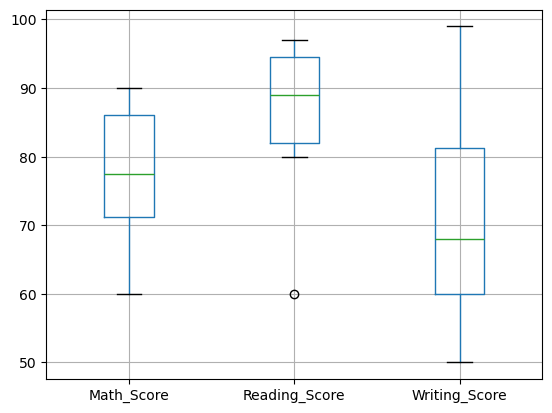

In [14]:
cols = ['Math_Score', 'Reading_Score', 'Writing_Score']
df.boxplot(column=cols)

In [15]:
df['Zscore'] = (df['Math_Score'] - df['Math_Score'].mean()) / df['Math_Score']

# Store outliers
outliers = df[(df['Zscore'] > 3) | (df['Zscore'] < -3)]

# Display output
print(outliers)
print("Total Outliers:", len(outliers))


Empty DataFrame
Columns: [Gender, Math_Score, Reading_Score, Writing_Score, Zscore]
Index: []
Total Outliers: 0


In [17]:
upper_limit = df['Math_Score'].mean() + 3 * df['Math_Score'].std()
lower_limit = df['Math_Score'].mean() - 3 * df['Math_Score'].std()

# Apply capping
df['Math_Score'] = np.where(df['Math_Score'] > upper_limit, upper_limit, df['Math_Score'])
df['Math_Score'] = np.where(df['Math_Score'] < lower_limit, lower_limit, df['Math_Score'])

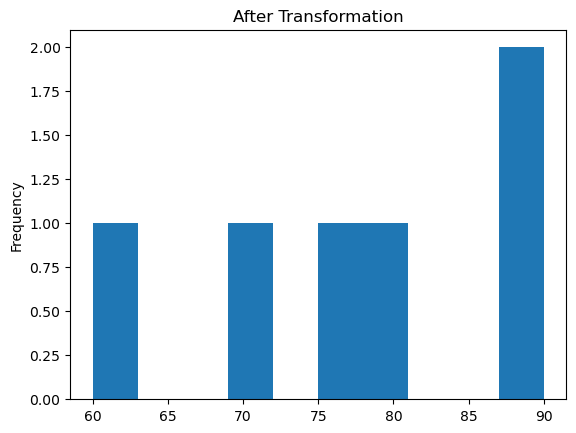

In [18]:
df['Math_Score'].plot(kind='hist') 
plt.title("After Transformation") 
plt.show()

In [20]:
df['Log_Math_Score'] = np.log10(df['Math_Score'])

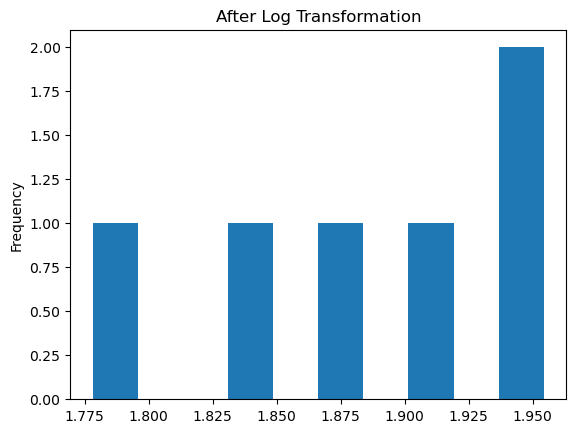

In [21]:
df['Log_Math_Score'].plot(kind='hist') 
plt.title("After Log Transformation") 
plt.show()

In [22]:
df.head()

,Gender,Math_Score,Reading_Score,Writing_Score,Zscore,Log_Math_Score
0,1,70.0,80,50,-0.102381,1.845098
1,1,80.0,90,66,0.035417,1.903090
2,1,60.0,60,85,-0.286111,1.778151
3,0,75.0,88,58,-0.028889,1.875061
4,0,90.0,97,99,0.142593,1.954243
